Cell 1 — Install / Imports Setup

In [ ]:
# Notebook Setup Cell

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
import time

In [ ]:
!pip install fastapi uvicorn

In [ ]:
from fastapi import FastAPI
from fastapi.testclient import TestClient
from typing import Dict, Any

In [ ]:
from typing import Dict, Any

In [ ]:
# Cell A1 — Load and Preprocess the AI4I Dataset

import os
import numpy as np
import pandas as pd

# Try common locations
possible_paths = [
    "/content/ai4i2020.csv",
    "/mnt/data/ai4i2020.csv",
    "ai4i2020.csv"
]

csv_path = None
for p in possible_paths:
    if os.path.exists(p):
        csv_path = p
        break

if csv_path is None:
    raise FileNotFoundError("Could not find ai4i2020.csv. Upload it to Colab or place it in /content/.")

ai4i_raw = pd.read_csv(csv_path)

print("Loaded AI4I dataset from:", csv_path)
print("Shape:", ai4i_raw.shape)
print(ai4i_raw.head())

Loaded AI4I dataset from: /content/ai4i2020.csv
Shape: (10000, 14)
   UDI Product ID Type  Air temperature [K]  Process temperature [K]  \
0    1     M14860    M                298.1                    308.6   
1    2     L47181    L                298.2                    308.7   
2    3     L47182    L                298.1                    308.5   
3    4     L47183    L                298.2                    308.6   
4    5     L47184    L                298.2                    308.7   

   Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  Machine failure  TWF  \
0                    1551         42.8                0                0    0   
1                    1408         46.3                3                0    0   
2                    1498         49.4                5                0    0   
3                    1433         39.5                7                0    0   
4                    1408         40.0                9                0    0   

   HDF  PWF  

Cell A2 — Convert AI4I into DDAK-Connect Data Format

In [ ]:
# Cell A2 — Convert AI4I into DDAK-Connect Data Format

def infer_failure_type(row):
    if row["TWF"] == 1:
        return "tool_wear_failure"
    if row["HDF"] == 1:
        return "heat_dissipation_failure"
    if row["PWF"] == 1:
        return "power_failure"
    if row["OSF"] == 1:
        return "overstrain_failure"
    if row["RNF"] == 1:
        return "random_failure"
    return "normal"

ai4i_df = ai4i_raw.copy()

# Create a deterministic timestamp sequence for the prototype
ai4i_df["timestamp"] = pd.Timestamp("2026-03-01") + pd.to_timedelta(ai4i_df["UDI"], unit="min")

# Create pseudo machine IDs for the simulation
ai4i_df["machine_id"] = ai4i_df.apply(
    lambda r: f"AI4I_{r['Type']}_{(int(r['UDI']) % 5) + 1}", axis=1
)

# Create pseudo shifts
shift_map = {0: "A", 1: "B", 2: "C"}
ai4i_df["shift"] = ai4i_df["UDI"].apply(lambda x: shift_map[int(x) % 3])

# Derive unified failure_type
ai4i_df["failure_type"] = ai4i_df.apply(infer_failure_type, axis=1)

# Rename key columns to match DDAK-Connect pipeline
ai4i_df = ai4i_df.rename(columns={
    "Air temperature [K]": "air_temperature_k",
    "Process temperature [K]": "temperature_k",
    "Rotational speed [rpm]": "spindle_speed_rpm",
    "Torque [Nm]": "torque_nm",
    "Tool wear [min]": "tool_wear_min",
    "Machine failure": "failure"
})

# Estimate mechanical power / energy proxy in kW
# P(kW) = Torque(Nm) * 2*pi*RPM / 60 / 1000
ai4i_df["energy_kw"] = (
    ai4i_df["torque_nm"] * (2 * np.pi * ai4i_df["spindle_speed_rpm"] / 60) / 1000
).round(3)

# Reorder useful columns
plc_df = ai4i_df[[
    "timestamp",
    "machine_id",
    "shift",
    "air_temperature_k",
    "temperature_k",
    "spindle_speed_rpm",
    "torque_nm",
    "tool_wear_min",
    "energy_kw",
    "failure",
    "failure_type",
    "Type",
    "Product ID"
]].copy()

print("Converted AI4I dataset for DDAK-Connect:")
print(plc_df.head())

print("\nFailure distribution:")
print(plc_df["failure"].value_counts())

print("\nFailure type distribution:")
print(plc_df["failure_type"].value_counts())

Converted AI4I dataset for DDAK-Connect:
            timestamp machine_id shift  air_temperature_k  temperature_k  \
0 2026-03-01 00:01:00   AI4I_M_2     B              298.1          308.6   
1 2026-03-01 00:02:00   AI4I_L_3     C              298.2          308.7   
2 2026-03-01 00:03:00   AI4I_L_4     A              298.1          308.5   
3 2026-03-01 00:04:00   AI4I_L_5     B              298.2          308.6   
4 2026-03-01 00:05:00   AI4I_L_1     C              298.2          308.7   

   spindle_speed_rpm  torque_nm  tool_wear_min  energy_kw  failure  \
0               1551       42.8              0      6.952        0   
1               1408       46.3              3      6.827        0   
2               1498       49.4              5      7.749        0   
3               1433       39.5              7      5.928        0   
4               1408       40.0              9      5.898        0   

  failure_type Type Product ID  
0       normal    M     M14860  
1       normal 

Cell A3 — Visualize the AI4I Telemetry

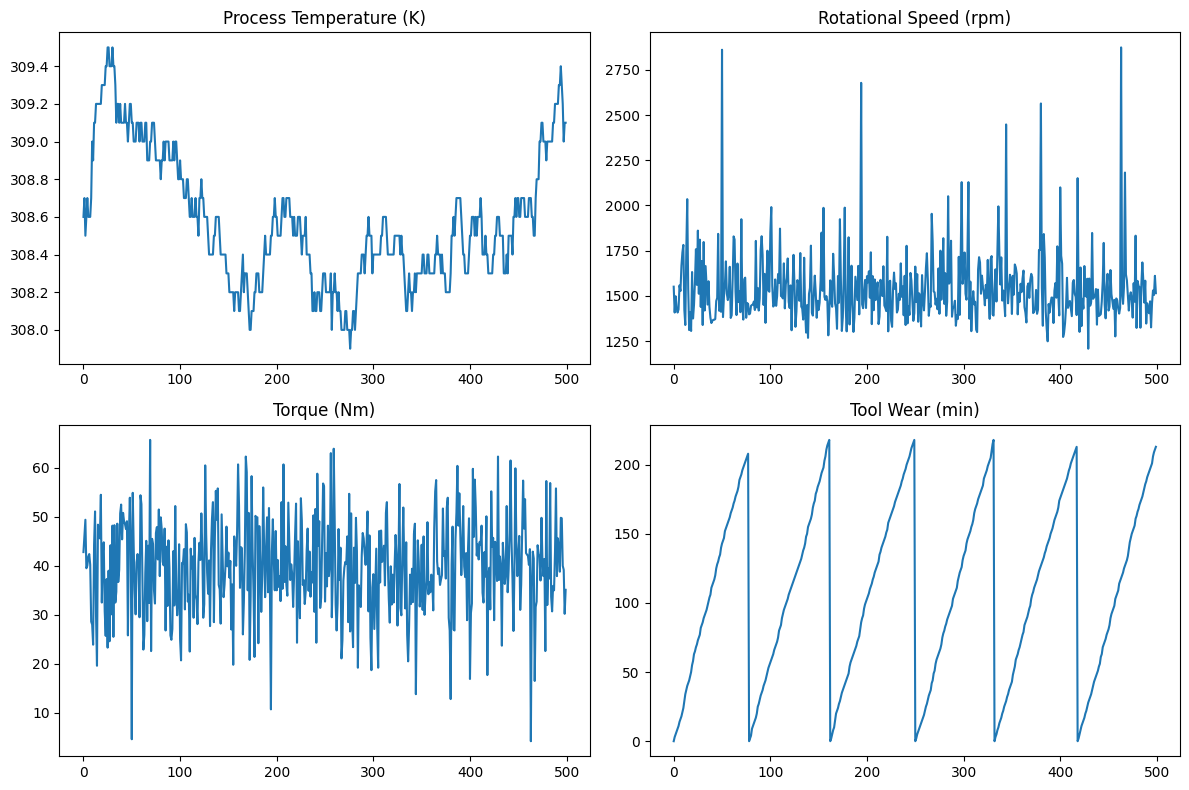

In [ ]:
# Cell A3 — Visualize AI4I Telemetry

import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

plc_df["temperature_k"].iloc[:500].plot(ax=axes[0, 0], title="Process Temperature (K)")
plc_df["spindle_speed_rpm"].iloc[:500].plot(ax=axes[0, 1], title="Rotational Speed (rpm)")
plc_df["torque_nm"].iloc[:500].plot(ax=axes[1, 0], title="Torque (Nm)")
plc_df["tool_wear_min"].iloc[:500].plot(ax=axes[1, 1], title="Tool Wear (min)")

plt.tight_layout()
plt.show()

Cell A4 — Reuse / Update the OPC-UA Snapshot Cell

In [ ]:
# Cell A4 — OPC-UA Snapshot for AI4I Data

OT_TAG_MAP = {
    "air_temperature_k": "ns=2;s=CNC.AirTemperature",
    "temperature_k": "ns=2;s=CNC.ProcessTemperature",
    "spindle_speed_rpm": "ns=2;s=CNC.SpindleSpeed",
    "torque_nm": "ns=2;s=CNC.Torque",
    "tool_wear_min": "ns=2;s=CNC.ToolWear",
    "energy_kw": "ns=2;s=CNC.EnergyKW",
    "machine_id": "ns=2;s=CNC.MachineID",
    "timestamp": "ns=2;s=CNC.Timestamp",
}

def plc_row_to_opcua_snapshot(row: pd.Series) -> Dict[str, Any]:
    snapshot = {}
    for column in OT_TAG_MAP.keys():
        value = row[column]
        if isinstance(value, (np.float32, np.float64)):
            value = float(value)
        if isinstance(value, (np.int32, np.int64)):
            value = int(value)
        snapshot[OT_TAG_MAP[column]] = value
    return snapshot

sample_snapshot = plc_row_to_opcua_snapshot(plc_df.iloc[0])

print("Sample OPC-UA snapshot from AI4I data:")
sample_snapshot

Sample OPC-UA snapshot from AI4I data:


{'ns=2;s=CNC.AirTemperature': 298.1,
 'ns=2;s=CNC.ProcessTemperature': 308.6,
 'ns=2;s=CNC.SpindleSpeed': 1551,
 'ns=2;s=CNC.Torque': 42.8,
 'ns=2;s=CNC.ToolWear': 0,
 'ns=2;s=CNC.EnergyKW': 6.952,
 'ns=2;s=CNC.MachineID': 'AI4I_M_2',
 'ns=2;s=CNC.Timestamp': Timestamp('2026-03-01 00:01:00')}

Cell A5 — Retrain the Edge Model on AI4I

In [ ]:
# Cell A5 — Retrain DDAK-Sense on AI4I Data

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split

features = [
    "air_temperature_k",
    "temperature_k",
    "spindle_speed_rpm",
    "torque_nm",
    "tool_wear_min",
    "energy_kw"
]

X = plc_df[features]
y = plc_df["failure"]

X_train, X_test, y_train, y_test, df_train, df_test = train_test_split(
    X, y, plc_df, test_size=0.25, random_state=42, stratify=y
)

sense_model = RandomForestClassifier(
    n_estimators=150,
    max_depth=10,
    random_state=42,
    class_weight="balanced"
)

sense_model.fit(X_train, y_train)

pred = sense_model.predict(X_test)
proba = sense_model.predict_proba(X_test)[:, 1]

print("AI4I Edge Sense Accuracy:", round(accuracy_score(y_test, pred), 4))
print("\nClassification report:\n")
print(classification_report(y_test, pred))

print("\nTraining failure distribution:")
print(y_train.value_counts())

print("\nTest failure distribution:")
print(y_test.value_counts())

AI4I Edge Sense Accuracy: 0.9788

Classification report:

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      2415
           1       0.71      0.64      0.67        85

    accuracy                           0.98      2500
   macro avg       0.85      0.81      0.83      2500
weighted avg       0.98      0.98      0.98      2500


Training failure distribution:
failure
0    7246
1     254
Name: count, dtype: int64

Test failure distribution:
failure
0    2415
1      85
Name: count, dtype: int64


Cell A6 — Update DDAK-Diagnose Rules for AI4I Fault Types

In [ ]:
# Cell A6 — AI4I-Specific Root Cause Diagnosis Logic

def diagnose_root_cause(row: Dict[str, Any]) -> str:
    air_temp = row["air_temperature_k"]
    process_temp = row["temperature_k"]
    speed = row["spindle_speed_rpm"]
    torque = row["torque_nm"]
    wear = row["tool_wear_min"]
    power_kw = row["energy_kw"]

    # AI4I-inspired heuristics
    # 1. Tool wear failure
    if wear > 200:
        return "tool_wear_failure"

    # 2. Heat dissipation failure (AI4I typically linked to low air-process delta and lower speed)
    if (process_temp - air_temp) < 8.6 and speed < 1380:
        return "heat_dissipation_failure"

    # 3. Power failure (approximate using mechanical power proxy)
    if power_kw < 3.5 or power_kw > 9.0:
        return "power_failure"

    # 4. Overstrain failure
    if torque * wear > 11000:
        return "overstrain_failure"

    # 5. Otherwise uncertain
    return "uncertain"

# Example
test_row = df_test.iloc[0].to_dict()
print("Actual failure type:", test_row["failure_type"])
print("Diagnosed failure type:", diagnose_root_cause(test_row))

Actual failure type: normal
Diagnosed failure type: uncertain


Cell A7 — Update the Cloud Failure Database for AI4I

In [ ]:
# Cell A7 — AI4I-Aligned Cloud Knowledge Service

from fastapi import FastAPI
from fastapi.testclient import TestClient
from typing import Dict, Any

cloud_app = FastAPI(title="Cloud Knowledge Service")

failure_case_db = [
    {
        "case_id": "AI4I-FC-001",
        "pattern": {
            "tool_wear_min": 220,
            "torque_nm": 45
        },
        "failure_type": "tool_wear_failure",
        "recommended_action": "Inspect and replace worn tooling before the next production cycle."
    },
    {
        "case_id": "AI4I-FC-002",
        "pattern": {
            "air_temperature_k": 298,
            "temperature_k": 306,
            "spindle_speed_rpm": 1350
        },
        "failure_type": "heat_dissipation_failure",
        "recommended_action": "Inspect cooling airflow and reduce spindle load."
    },
    {
        "case_id": "AI4I-FC-003",
        "pattern": {
            "energy_kw": 9.5,
            "torque_nm": 52
        },
        "failure_type": "power_failure",
        "recommended_action": "Check motor load and electrical power conditions."
    },
    {
        "case_id": "AI4I-FC-004",
        "pattern": {
            "tool_wear_min": 210,
            "torque_nm": 55
        },
        "failure_type": "overstrain_failure",
        "recommended_action": "Reduce machining load and inspect machine components."
    },
]

@cloud_app.post("/failure_cases/search")
def search_failure_cases(payload: Dict[str, Any]):

    matches = []

    for case in failure_case_db:
        score = 0
        pattern = case["pattern"]

        for key, val in pattern.items():
            if key in payload:

                if isinstance(val, (int, float)):
                    if abs(payload[key] - val) < max(5, 0.1 * abs(val)):
                        score += 1

        if score >= 1:
            matches.append({**case, "match_score": score})

    matches = sorted(matches, key=lambda x: x["match_score"], reverse=True)

    return {
        "matches": matches,
        "num_matches": len(matches)
    }


@cloud_app.get("/benchmarks/{machine_id}")
def get_benchmarks(machine_id: str):

    return {
        "machine_id": machine_id,
        "avg_temperature_k": round(plc_df["temperature_k"].mean(), 2),
        "avg_spindle_speed_rpm": round(plc_df["spindle_speed_rpm"].mean(), 2),
        "avg_torque_nm": round(plc_df["torque_nm"].mean(), 2),
        "avg_tool_wear_min": round(plc_df["tool_wear_min"].mean(), 2),
        "note": "Values above benchmark thresholds should be inspected."
    }


cloud_client = TestClient(cloud_app)

# Example query
test_payload = df_test.iloc[0][[
    "air_temperature_k",
    "temperature_k",
    "spindle_speed_rpm",
    "torque_nm",
    "tool_wear_min",
    "energy_kw"
]].to_dict()

print("Example cloud failure search result:")
print(cloud_client.post("/failure_cases/search", json=test_payload).json())

Example cloud failure search result:
{'matches': [{'case_id': 'AI4I-FC-002', 'pattern': {'air_temperature_k': 298, 'temperature_k': 306, 'spindle_speed_rpm': 1350}, 'failure_type': 'heat_dissipation_failure', 'recommended_action': 'Inspect cooling airflow and reduce spindle load.', 'match_score': 3}, {'case_id': 'AI4I-FC-003', 'pattern': {'energy_kw': 9.5, 'torque_nm': 52}, 'failure_type': 'power_failure', 'recommended_action': 'Check motor load and electrical power conditions.', 'match_score': 2}, {'case_id': 'AI4I-FC-004', 'pattern': {'tool_wear_min': 210, 'torque_nm': 55}, 'failure_type': 'overstrain_failure', 'recommended_action': 'Reduce machining load and inspect machine components.', 'match_score': 1}], 'num_matches': 3}


In [ ]:
# Cell A8 — Ensure Features Match AI4I

features = [
    "air_temperature_k",
    "temperature_k",
    "spindle_speed_rpm",
    "torque_nm",
    "tool_wear_min",
    "energy_kw"
]

print("AI4I feature list updated.")

AI4I feature list updated.


Cell 8 — Policy Engine

In [ ]:
# Cell 8 — Policy Engine (Updated for AI4I / Realistic Cloud Sanitization)

from dataclasses import dataclass
from typing import Dict, Any, List, Optional
import json
import numpy as np

@dataclass
class PolicyConfig:
    enable_cloud: bool = True
    min_anomaly_probability: float = 0.40
    redact_fields: Optional[List[str]] = None


# Default policy configuration
policy = PolicyConfig(
    enable_cloud=True,
    min_anomaly_probability=0.40,
    redact_fields=["timestamp", "Product ID", "UDI"]
)

def to_python_native(value):
    """Convert numpy / pandas scalar types to native Python types."""
    if isinstance(value, (np.float32, np.float64)):
        return float(value)
    if isinstance(value, (np.int32, np.int64)):
        return int(value)
    return value


def evaluate_cloud_policy(event_payload: Dict[str, Any],
                          anomaly_probability: float,
                          policy: PolicyConfig) -> Dict[str, Any]:
    """
    Evaluate whether cloud interaction is authorized.
    Also sanitize payload by removing redacted fields and converting values
    to JSON-friendly Python native types.
    """
    if not policy.enable_cloud:
        return {
            "authorized": False,
            "reason": "Cloud interaction disabled by policy."
        }

    if anomaly_probability < policy.min_anomaly_probability:
        return {
            "authorized": False,
            "reason": f"Anomaly probability {anomaly_probability:.2f} below policy threshold."
        }

    sanitized_payload = {}

    for key, value in dict(event_payload).items():
        if key not in (policy.redact_fields or []):
            sanitized_payload[key] = to_python_native(value)

    return {
        "authorized": True,
        "reason": "Authorized by policy.",
        "payload": sanitized_payload
    }


# Example test with one AI4I row
test_event = plc_df.iloc[10].to_dict()
test_anomaly_probability = 0.72

policy_result = evaluate_cloud_policy(
    event_payload=test_event,
    anomaly_probability=test_anomaly_probability,
    policy=policy
)

print("Policy evaluation result:")
print(json.dumps(policy_result, indent=2, default=str))

Policy evaluation result:
{
  "authorized": true,
  "reason": "Authorized by policy.",
  "payload": {
    "machine_id": "AI4I_H_2",
    "shift": "C",
    "air_temperature_k": 298.4,
    "temperature_k": 308.9,
    "spindle_speed_rpm": 1782,
    "torque_nm": 23.9,
    "tool_wear_min": 24,
    "energy_kw": 4.46,
    "failure": 0,
    "failure_type": "normal",
    "Type": "H"
  }
}


In [ ]:
# Optional extra test for Cell 8

test_event = plc_df.iloc[10].to_dict()

low_score_result = evaluate_cloud_policy(
    event_payload=test_event,
    anomaly_probability=0.20,
    policy=policy
)

high_score_result = evaluate_cloud_policy(
    event_payload=test_event,
    anomaly_probability=0.85,
    policy=policy
)

print("Low anomaly score result:")
print(json.dumps(low_score_result, indent=2, default=str))

print("\nHigh anomaly score result:")
print(json.dumps(high_score_result, indent=2, default=str))

Low anomaly score result:
{
  "authorized": false,
  "reason": "Anomaly probability 0.20 below policy threshold."
}

High anomaly score result:
{
  "authorized": true,
  "reason": "Authorized by policy.",
  "payload": {
    "machine_id": "AI4I_H_2",
    "shift": "C",
    "air_temperature_k": 298.4,
    "temperature_k": 308.9,
    "spindle_speed_rpm": 1782,
    "torque_nm": 23.9,
    "tool_wear_min": 24,
    "energy_kw": 4.46,
    "failure": 0,
    "failure_type": "normal",
    "Type": "H"
  }
}


Cell 9 — Edge Intelligence (Sense → Diagnose)

In [ ]:
# Cell 9 — Edge Intelligence (Sense → Diagnose) for AI4I

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from typing import Dict, Any

# Features used by the edge model for AI4I
features = [
    "air_temperature_k",
    "temperature_k",
    "spindle_speed_rpm",
    "torque_nm",
    "tool_wear_min",
    "energy_kw"
]

X = plc_df[features]
y = plc_df["failure"]

# Train / test split
X_train, X_test, y_train, y_test, df_train, df_test = train_test_split(
    X, y, plc_df, test_size=0.25, random_state=42, stratify=y
)

# DDAK-Sense model
sense_model = RandomForestClassifier(
    n_estimators=150,
    max_depth=10,
    random_state=42,
    class_weight="balanced"
)

sense_model.fit(X_train, y_train)

# Evaluate edge detection performance
pred = sense_model.predict(X_test)
proba = sense_model.predict_proba(X_test)[:, 1]

print("AI4I Edge Sense Accuracy:", round(accuracy_score(y_test, pred), 4))
print("\nClassification report:\n")
print(classification_report(y_test, pred))

print("\nTraining failure distribution:")
print(y_train.value_counts())

print("\nTest failure distribution:")
print(y_test.value_counts())


# DDAK-Diagnose: AI4I-aligned root-cause logic
def diagnose_root_cause(row: Dict[str, Any]) -> str:
    air_temp = row["air_temperature_k"]
    process_temp = row["temperature_k"]
    speed = row["spindle_speed_rpm"]
    torque = row["torque_nm"]
    wear = row["tool_wear_min"]
    power_kw = row["energy_kw"]

    # 1. Tool wear failure
    if wear > 200:
        return "tool_wear_failure"

    # 2. Heat dissipation failure
    # AI4I typically associates this with lower rotational speed
    # and an unusual temperature relationship
    if (process_temp - air_temp) < 8.6 and speed < 1380:
        return "heat_dissipation_failure"

    # 3. Power failure
    # Approximate using derived mechanical power proxy
    if power_kw < 3.5 or power_kw > 9.0:
        return "power_failure"

    # 4. Overstrain failure
    if torque * wear > 11000:
        return "overstrain_failure"

    # 5. Random failure is not easily inferable from deterministic rules
    return "uncertain"


# Example diagnosis on one test row
test_row = df_test.iloc[0].to_dict()
example_diagnosis = diagnose_root_cause(test_row)

print("\nExample test row failure type:", test_row["failure_type"])
print("Diagnosed root cause:", example_diagnosis)

AI4I Edge Sense Accuracy: 0.9788

Classification report:

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      2415
           1       0.71      0.64      0.67        85

    accuracy                           0.98      2500
   macro avg       0.85      0.81      0.83      2500
weighted avg       0.98      0.98      0.98      2500


Training failure distribution:
failure
0    7246
1     254
Name: count, dtype: int64

Test failure distribution:
failure
0    2415
1      85
Name: count, dtype: int64

Example test row failure type: normal
Diagnosed root cause: uncertain


In [ ]:
print("Training failure distribution:")
print(y_train.value_counts())

print("\nTest failure distribution:")
print(y_test.value_counts())

Training failure distribution:
failure
0    7246
1     254
Name: count, dtype: int64

Test failure distribution:
failure
0    2415
1      85
Name: count, dtype: int64


In [ ]:
# Set your OpenAI API key

import os

os.environ["OPENAI_API_KEY"] = "xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx" #Insert your API key here

print("OpenAI API key loaded.")

OpenAI API key loaded.


📦 Cell 10 — LLM Reasoning Module

In [ ]:
# Cell 10 — LLM Reasoning (Updated for AI4I)

import os

USE_OPENAI = bool(os.getenv("OPENAI_API_KEY"))

def build_llm_prompt(local_context, diagnosis, erp_context, cloud_context):
    prompt = f"""
You are an industrial AI assistant inside the DDAK-Connect system.

Machine telemetry:
Air temperature: {local_context['air_temperature_k']} K
Process temperature: {local_context['temperature_k']} K
Rotational speed: {local_context['spindle_speed_rpm']} rpm
Torque: {local_context['torque_nm']} Nm
Tool wear: {local_context['tool_wear_min']} min
Estimated power: {local_context['energy_kw']} kW

Edge diagnosis:
{diagnosis}

ERP / MES context:
{erp_context}

Cloud knowledge matches:
{cloud_context}

Your task:
1. Explain the most likely issue in simple industrial language.
2. State the most probable cause.
3. Recommend a practical operator action.
4. Keep the answer concise and useful for a factory operator.

Respond in 3 numbered points.
"""
    return prompt


def fallback_llm_response(diagnosis):
    if diagnosis == "tool_wear_failure":
        return (
            "1. The machine shows symptoms consistent with excessive tool wear.\n"
            "2. The most likely cause is prolonged tool usage beyond normal operating limits.\n"
            "3. Inspect the cutting tool and replace it if wear exceeds acceptable thresholds."
        )

    if diagnosis == "heat_dissipation_failure":
        return (
            "1. The machine may be experiencing a heat dissipation issue.\n"
            "2. The most likely cause is insufficient cooling or abnormal thermal balance during operation.\n"
            "3. Inspect cooling airflow or coolant performance and reduce machine load if necessary."
        )

    if diagnosis == "power_failure":
        return (
            "1. The machine may be operating outside normal power conditions.\n"
            "2. The most likely cause is abnormal load or power transmission behavior.\n"
            "3. Inspect the motor load, electrical conditions, and transmission components."
        )

    if diagnosis == "overstrain_failure":
        return (
            "1. The machine may be under excessive mechanical strain.\n"
            "2. The likely cause is the combination of high torque and accumulated tool wear.\n"
            "3. Reduce machining load and inspect the machine for overstrain-related wear or damage."
        )

    return (
        "1. No clear fault pattern was confirmed by the local edge diagnosis.\n"
        "2. The current telemetry suggests that the machine should be monitored more closely.\n"
        "3. Continue operation with caution and inspect the machine if abnormal behavior persists."
    )


def run_llm_reasoning(local_context, diagnosis, erp_context, cloud_context):
    if not USE_OPENAI:
        return fallback_llm_response(diagnosis)

    from openai import OpenAI
    client = OpenAI()

    prompt = build_llm_prompt(local_context, diagnosis, erp_context, cloud_context)

    response = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[
            {
                "role": "system",
                "content": (
                    "You are an industrial diagnostic assistant for DDAK-Connect. "
                    "You explain machine conditions clearly, cautiously, and practically "
                    "for factory operators in a human-centric Industry 5.0 setting."
                )
            },
            {"role": "user", "content": prompt}
        ],
        temperature=0.2
    )

    return response.choices[0].message.content.strip()

ERP / MES Simulation API

In [ ]:
# ERP / MES Context Simulation (Required for Orchestration)

from fastapi import FastAPI
from fastapi.testclient import TestClient
import random

erp_app = FastAPI(title="ERP MES Context Service")

@erp_app.get("/machine/{machine_id}/context")
def get_machine_context(machine_id: str):

    return {
        "machine_id": machine_id,
        "maintenance": {
            "last_maintenance": f"2026-02-{random.randint(1,28)}",
            "recent_failures": random.sample(
                [
                    "tool_wear_failure",
                    "heat_dissipation_failure",
                    "power_failure",
                    "overstrain_failure"
                ],
                random.randint(0, 2)
            ),
            "production_order": f"PO-{random.randint(1000,1010)}",
            "maintenance_team": random.choice(["Team_A","Team_B","Team_C"])
        },
        "line_supervisor": f"Supervisor_{random.randint(1,5)}",
        "current_shift_target": random.randint(80,120),
        "current_shift_progress": random.randint(20,80),
        "mes_status": random.choice(["running","under_observation","maintenance"])
    }

erp_client = TestClient(erp_app)

print("ERP / MES simulation service initialized.")

ERP / MES simulation service initialized.


Cell 11 — End-to-End DDAK-Connect Orchestration

In [ ]:
# Cell 11 — End-to-End DDAK-Connect Orchestration
# Updated with confidence-aware cloud refinement

def run_ddak_connect_case(row: pd.Series, policy: PolicyConfig):
    timings = {}

    # Convert row once for reuse
    local_context = row.to_dict()

    # -----------------------------
    # 1. OT ingestion
    # -----------------------------
    t0 = time.time()
    opcua_snapshot = plc_row_to_opcua_snapshot(row)
    timings["ot_ingestion_ms"] = (time.time() - t0) * 1000

    # -----------------------------
    # 2. IT ingestion
    # -----------------------------
    t1 = time.time()
    erp_context = erp_client.get(f"/machine/{row['machine_id']}/context").json()
    timings["it_ingestion_ms"] = (time.time() - t1) * 1000

    # -----------------------------
    # 3. Edge intelligence (Sense)
    # -----------------------------
    t2 = time.time()

    # Keep feature names for sklearn consistency
    local_features = pd.DataFrame([row[features]], columns=features)

    anomaly_probability = float(sense_model.predict_proba(local_features)[0, 1])
    local_prediction = int(sense_model.predict(local_features)[0])
    diagnosis = diagnose_root_cause(local_context)

    timings["edge_analysis_ms"] = (time.time() - t2) * 1000

    # -----------------------------
    # 4. Policy-governed cloud interaction
    # -----------------------------
    t3 = time.time()

    policy_result = evaluate_cloud_policy(
        event_payload=local_context,
        anomaly_probability=anomaly_probability,
        policy=policy
    )

    cloud_context = {"matches": [], "benchmarks": {}}

    if policy_result["authorized"]:
        cloud_context = cloud_client.post(
            "/failure_cases/search",
            json=policy_result["payload"]
        ).json()

        cloud_context["benchmarks"] = cloud_client.get(
            f"/benchmarks/{row['machine_id']}"
        ).json()

    timings["cloud_interaction_ms"] = (time.time() - t3) * 1000

    # -----------------------------
    # 4b. Confidence-aware hybrid refinement of diagnosis
    # -----------------------------
    refined_by_cloud = False

    if diagnosis == "uncertain" and policy_result["authorized"]:
        matches = cloud_context.get("matches", [])

        if matches:
            top_case = matches[0]["failure_type"]
            match_score = matches[0].get("match_score", 0)

            # Apply cloud refinement only if:
            # 1. The cloud match is sufficiently strong
            # 2. The anomaly probability is also reasonably high
            if match_score >= 2 and anomaly_probability >= 0.65:
                diagnosis = top_case
                refined_by_cloud = True

    # -----------------------------
    # 5. LLM reasoning
    # -----------------------------
    t4 = time.time()

    llm_explanation = run_llm_reasoning(
        local_context=local_context,
        diagnosis=diagnosis,
        erp_context=erp_context,
        cloud_context=cloud_context
    )

    timings["llm_reasoning_ms"] = (time.time() - t4) * 1000

    # -----------------------------
    # 6. Final operator result
    # -----------------------------
    result = {
        "machine_id": row["machine_id"],
        "timestamp": str(row["timestamp"]),
        "actual_failure": int(row["failure"]),
        "actual_failure_type": row["failure_type"],
        "predicted_failure": local_prediction,
        "anomaly_probability": round(anomaly_probability, 4),
        "diagnosis": diagnosis,
        "refined_by_cloud": refined_by_cloud,
        "cloud_used": policy_result["authorized"],
        "policy_reason": policy_result["reason"],
        "opcua_snapshot": opcua_snapshot,
        "erp_context": erp_context,
        "cloud_context": cloud_context,
        "llm_explanation": llm_explanation,
        "timings_ms": {k: round(v, 2) for k, v in timings.items()},
        "total_latency_ms": round(sum(timings.values()), 2)
    }

    return result

Cell 12 — Run One Full DDAK-Connect Example

In [ ]:
# Cell 12 — Run One Full DDAK-Connect Example (AI4I Version)

import json

# Use a test row — you can change the index to inspect different cases
example_row = df_test.iloc[10]

example_result = run_ddak_connect_case(example_row, policy)

print("=" * 100)
print("DDAK-Connect Full Case Result (AI4I Evaluation)")
print("=" * 100)

print("\nMachine ID:", example_result["machine_id"])
print("Timestamp:", example_result["timestamp"])
print("Machine Type:", example_row["Type"])

print("\nTelemetry Snapshot:")
print("Air temperature (K):", example_row["air_temperature_k"])
print("Process temperature (K):", example_row["temperature_k"])
print("Rotational speed (rpm):", example_row["spindle_speed_rpm"])
print("Torque (Nm):", example_row["torque_nm"])
print("Tool wear (min):", example_row["tool_wear_min"])
print("Estimated power (kW):", example_row["energy_kw"])

print("Actual failure type:", example_result["actual_failure_type"])
print("Predicted failure:", example_result["predicted_failure"])
print("Anomaly probability:", example_result["anomaly_probability"])
print("Diagnosis:", example_result["diagnosis"])
print("Refined by cloud:", example_result["refined_by_cloud"])
print("Cloud used:", example_result["cloud_used"])
print("Policy reason:", example_result["policy_reason"])

print("\nERP / MES Context:")
print(json.dumps(example_result["erp_context"], indent=2))

print("\nCloud Context:")
print(json.dumps(example_result["cloud_context"], indent=2))

print("\nLLM Explanation:")
print(example_result["llm_explanation"])

print("\nTimings (ms):")
print(json.dumps(example_result["timings_ms"], indent=2))

print("\nTotal latency (ms):", example_result["total_latency_ms"])

DDAK-Connect Full Case Result (AI4I Evaluation)

Machine ID: AI4I_L_1
Timestamp: 2026-03-02 18:00:00
Machine Type: L

Telemetry Snapshot:
Air temperature (K): 298.8
Process temperature (K): 308.6
Rotational speed (rpm): 1631
Torque (Nm): 32.4
Tool wear (min): 38
Estimated power (kW): 5.534
Actual failure type: normal
Predicted failure: 0
Anomaly probability: 0.0019
Diagnosis: uncertain
Refined by cloud: False
Cloud used: False
Policy reason: Anomaly probability 0.00 below policy threshold.

ERP / MES Context:
{
  "machine_id": "AI4I_L_1",
  "maintenance": {
    "last_maintenance": "2026-02-27",
    "recent_failures": [
      "tool_wear_failure",
      "heat_dissipation_failure"
    ],
    "production_order": "PO-1002",
    "maintenance_team": "Team_C"
  },
  "line_supervisor": "Supervisor_1",
  "current_shift_target": 84,
  "current_shift_progress": 26,
  "mes_status": "maintenance"
}

Cloud Context:
{
  "matches": [],
  "benchmarks": {}
}

LLM Explanation:
1. **Most Likely Issue**: Th

Cell 13 — Batch Evaluation (Edge Only vs Hybrid)

In [ ]:
# Cell 13 — Batch Evaluation (Edge Only vs Hybrid) for AI4I

def diagnosis_success(actual: str, predicted: str) -> int:
    """
    Simple diagnostic match scoring for AI4I fault labels.
    """
    if actual == "normal" and predicted in ["uncertain", "normal"]:
        return 1
    if actual == predicted:
        return 1
    return 0


def compute_augmented_diagnosis_score(row):
    """
    Gives a small quality boost when cloud knowledge retrieves
    a matching historical case.
    """
    base = 1.0 if diagnosis_success(row["actual_failure_type"], row["diagnosis"]) else 0.0
    boost = 0.0

    cloud_context = row.get("cloud_context", {})
    matches = cloud_context.get("matches", []) if isinstance(cloud_context, dict) else []

    if row["cloud_used"] and matches:
        top_case = matches[0]["failure_type"]
        if top_case == row["actual_failure_type"]:
            boost = 0.2

    return min(base + boost, 1.0)


def evaluate_pipeline(df_eval: pd.DataFrame, enable_cloud: bool, n_cases: int = 80):
    local_policy = PolicyConfig(
        enable_cloud=enable_cloud,
        min_anomaly_probability=0.40,
        redact_fields=["timestamp", "Product ID", "UDI"]
    )

    results = []
    sampled = df_eval.sample(min(n_cases, len(df_eval)), random_state=42)

    for _, row in sampled.iterrows():
        result = run_ddak_connect_case(row, local_policy)
        results.append(result)

    results_df = pd.DataFrame(results)

    # Diagnosis quality scoring
    results_df["diagnosis_match"] = [
        diagnosis_success(actual, predicted)
        for actual, predicted in zip(results_df["actual_failure_type"], results_df["diagnosis"])
    ]

    results_df["augmented_diagnosis_score"] = results_df.apply(
        compute_augmented_diagnosis_score, axis=1
    )

    return results_df


# Run both modes
results_edge_only = evaluate_pipeline(df_test, enable_cloud=False, n_cases=80)
results_hybrid = evaluate_pipeline(df_test, enable_cloud=True, n_cases=80)

print("Edge-only results shape:", results_edge_only.shape)
print("Hybrid results shape:", results_hybrid.shape)

Edge-only results shape: (80, 18)
Hybrid results shape: (80, 18)


Cell 14 — Results Summary Table

In [ ]:
# Cell 14 — Results Summary Table (AI4I Version)

n_eval_cases = len(results_edge_only)

summary = pd.DataFrame({
    "Mode": ["Edge Only", "Hybrid Edge + Cloud"],
    "Cloud Usage Rate": [
        round(results_edge_only["cloud_used"].mean(), 3),
        round(results_hybrid["cloud_used"].mean(), 3),
    ],
    "Mean Latency (ms)": [
        round(results_edge_only["total_latency_ms"].mean(), 2),
        round(results_hybrid["total_latency_ms"].mean(), 2),
    ],
    "Failure Detection Accuracy": [
        round((results_edge_only["actual_failure"] == results_edge_only["predicted_failure"]).mean(), 3),
        round((results_hybrid["actual_failure"] == results_hybrid["predicted_failure"]).mean(), 3),
    ],
    "Diagnosis Match Rate": [
        round(results_edge_only["diagnosis_match"].mean(), 3),
        round(results_hybrid["diagnosis_match"].mean(), 3),
    ],
    "Diagnostic Quality Score": [
        round(results_edge_only["augmented_diagnosis_score"].mean(), 3),
        round(results_hybrid["augmented_diagnosis_score"].mean(), 3),
    ]
})

print(f"DDAK-Connect AI4I Evaluation Summary (n={n_eval_cases} cases)")
summary

DDAK-Connect AI4I Evaluation Summary (n=80 cases)


,Mode,Cloud Usage Rate,Mean Latency (ms),Failure Detection Accuracy,Diagnosis Match Rate,Diagnostic Quality Score
0,Edge Only,0.00,2412.11,0.95,0.862,0.862
1,Hybrid Edge + Cloud,0.05,2569.82,0.95,0.850,0.850


In [ ]:
# Inspect cloud refinement behavior in hybrid mode

hyb = results_hybrid.copy()

print("Cloud used count:", int(hyb["cloud_used"].sum()))
print("Refined by cloud count:", int(hyb["refined_by_cloud"].sum()) if "refined_by_cloud" in hyb.columns else "not available")

if "refined_by_cloud" in hyb.columns:
    refined = hyb[hyb["refined_by_cloud"] == True].copy()
    print("\nRefined cases summary:")
    print(refined[["actual_failure_type", "diagnosis", "anomaly_probability"]].head(10))
    print("\nRefined-case diagnosis match rate:")
    if len(refined) > 0:
        print((refined["actual_failure_type"] == refined["diagnosis"]).mean())
    else:
        print("No refined cases")

Cloud used count: 4
Refined by cloud count: 1

Refined cases summary:
  actual_failure_type                 diagnosis  anomaly_probability
9              normal  heat_dissipation_failure               0.6971

Refined-case diagnosis match rate:
0.0


In [ ]:
# Policy Threshold Sensitivity Experiment

thresholds = [0.20, 0.30, 0.40, 0.50]

policy_results = []

for threshold in thresholds:

    local_policy = PolicyConfig(
        enable_cloud=True,
        min_anomaly_probability=threshold,
        redact_fields=["timestamp", "Product ID", "UDI"]
    )

    results = []

    sampled = df_test.sample(min(80, len(df_test)), random_state=42)

    for _, row in sampled.iterrows():
        result = run_ddak_connect_case(row, local_policy)
        results.append(result)

    results_df = pd.DataFrame(results)

    results_df["diagnosis_match"] = [
        diagnosis_success(a, p)
        for a, p in zip(results_df["actual_failure_type"], results_df["diagnosis"])
    ]

    results_df["augmented_diagnosis_score"] = results_df.apply(
        compute_augmented_diagnosis_score, axis=1
    )

    policy_results.append({
        "Threshold": threshold,
        "Cloud Usage Rate": results_df["cloud_used"].mean(),
        "Mean Latency (ms)": results_df["total_latency_ms"].mean(),
        "Diagnostic Quality": results_df["augmented_diagnosis_score"].mean()
    })

policy_sensitivity_df = pd.DataFrame(policy_results)

print("Policy Threshold Sensitivity Results")
display(policy_sensitivity_df)

Policy Threshold Sensitivity Results


,Threshold,Cloud Usage Rate,Mean Latency (ms),Diagnostic Quality
0,0.2,0.1125,2880.990000,0.85
1,0.3,0.1000,2644.532875,0.85
2,0.4,0.0500,2513.805250,0.85
3,0.5,0.0500,2278.736375,0.85


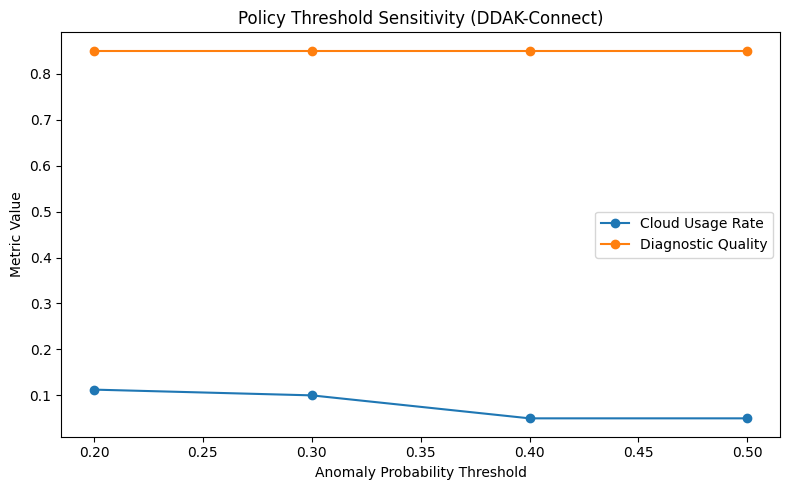

In [ ]:
# Plot Policy Sensitivity

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    policy_sensitivity_df["Threshold"],
    policy_sensitivity_df["Cloud Usage Rate"],
    marker="o",
    label="Cloud Usage Rate"
)

plt.plot(
    policy_sensitivity_df["Threshold"],
    policy_sensitivity_df["Diagnostic Quality"],
    marker="o",
    label="Diagnostic Quality"
)

plt.xlabel("Anomaly Probability Threshold")
plt.ylabel("Metric Value")
plt.title("Policy Threshold Sensitivity (DDAK-Connect)")
plt.legend()

plt.tight_layout()
plt.show()

Cell 15 — Visual Comparison

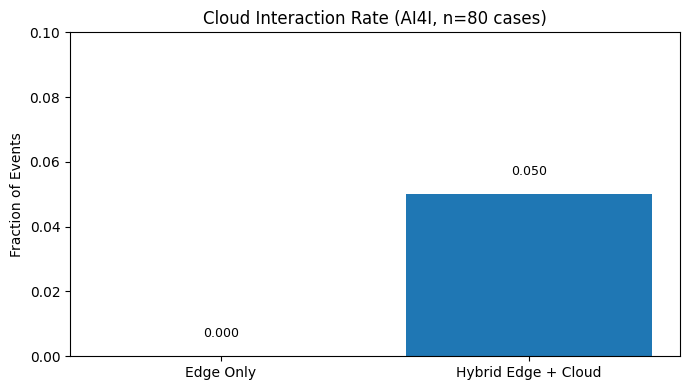

In [ ]:
# Plot 1 — Cloud Interaction Rate (AI4I)

import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(7, 4))

labels = ["Edge Only", "Hybrid Edge + Cloud"]
cloud_usage = [0, summary.loc[1, "Cloud Usage Rate"]]

bars = plt.bar(labels, cloud_usage)

plt.title(f"Cloud Interaction Rate (AI4I, n={len(results_edge_only)} cases)")
plt.ylabel("Fraction of Events")
plt.ylim(0, max(cloud_usage) + 0.05)

for bar in bars:
    height = bar.get_height()
    label = f"{height:.3f}" if height > 0.0001 else "0.000"
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.005,
        label,
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()

Updated Plot 2 — Diagnostic Quality

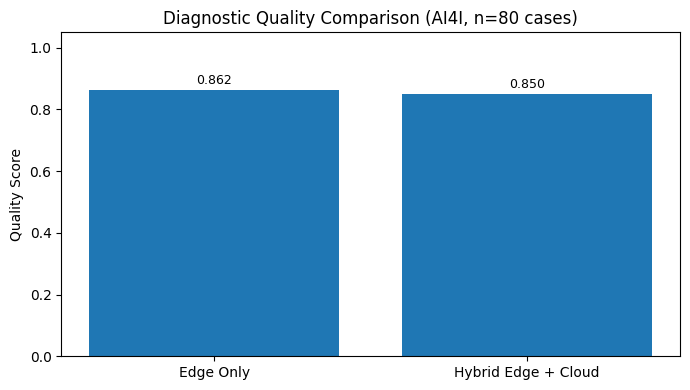

In [ ]:
# Plot 2 — Diagnostic Quality Comparison (AI4I)

plt.figure(figsize=(7, 4))

labels = summary["Mode"]
values = summary["Diagnostic Quality Score"]

bars = plt.bar(labels, values)

plt.title(f"Diagnostic Quality Comparison (AI4I, n={len(results_edge_only)} cases)")
plt.ylabel("Quality Score")
plt.ylim(0, 1.05)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.01,
        f"{height:.3f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()

Updated Plot 3 — Average End-to-End Processing Latency

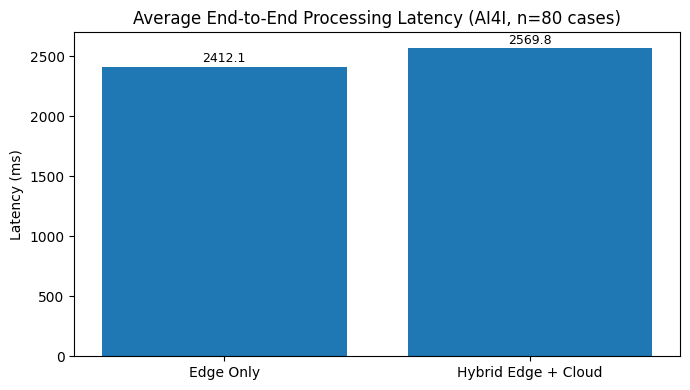

In [ ]:
# Plot 3 — Average End-to-End Processing Latency (AI4I)

plt.figure(figsize=(7, 4))

labels = summary["Mode"]
values = summary["Mean Latency (ms)"]

bars = plt.bar(labels, values)

plt.title(f"Average End-to-End Processing Latency (AI4I, n={len(results_edge_only)} cases)")
plt.ylabel("Latency (ms)")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 10,
        f"{height:.1f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()

New Plot 4 — Latency Breakdown by Pipeline Stage

In [ ]:
# Preparation — Flatten timing columns for latency breakdown

def flatten_timing_columns(results_df: pd.DataFrame) -> pd.DataFrame:
    timing_df = results_df["timings_ms"].apply(pd.Series)
    return pd.concat([results_df.drop(columns=["timings_ms"]), timing_df], axis=1)

results_edge_only_flat = flatten_timing_columns(results_edge_only)
results_hybrid_flat = flatten_timing_columns(results_hybrid)

print("Timing columns flattened successfully.")

Timing columns flattened successfully.


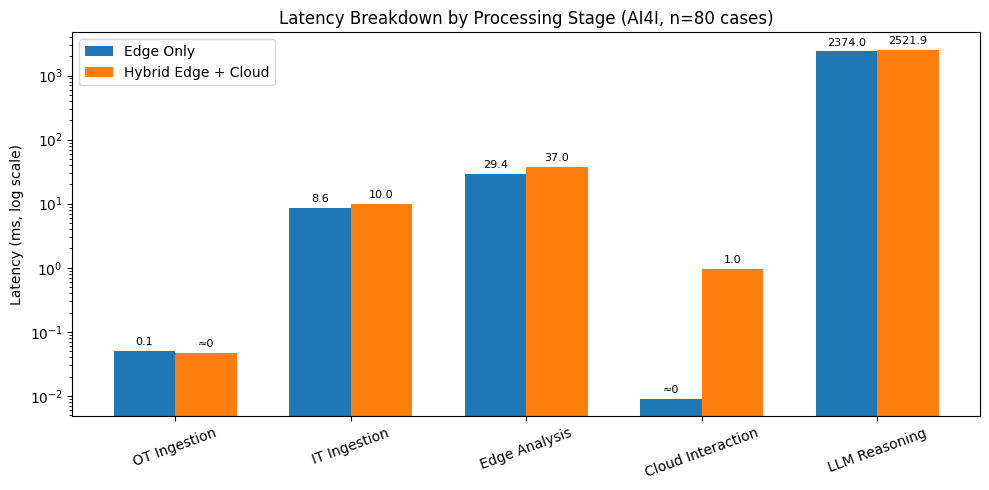

In [ ]:
# Plot 4 — Latency Breakdown by Processing Stage (AI4I)

latency_components = [
    "ot_ingestion_ms",
    "it_ingestion_ms",
    "edge_analysis_ms",
    "cloud_interaction_ms",
    "llm_reasoning_ms"
]

edge_only_latency = [
    results_edge_only_flat[c].mean() for c in latency_components
]

hybrid_latency = [
    results_hybrid_flat[c].mean() for c in latency_components
]

latency_breakdown_df = pd.DataFrame({
    "Component": [
        "OT Ingestion",
        "IT Ingestion",
        "Edge Analysis",
        "Cloud Interaction",
        "LLM Reasoning"
    ],
    "Edge Only": edge_only_latency,
    "Hybrid Edge + Cloud": hybrid_latency
})

x = np.arange(len(latency_breakdown_df["Component"]))
width = 0.35

plt.figure(figsize=(10, 5))

bars1 = plt.bar(x - width/2, latency_breakdown_df["Edge Only"], width, label="Edge Only")
bars2 = plt.bar(x + width/2, latency_breakdown_df["Hybrid Edge + Cloud"], width, label="Hybrid Edge + Cloud")

plt.xticks(x, latency_breakdown_df["Component"], rotation=20)
plt.ylabel("Latency (ms, log scale)")
plt.title(f"Latency Breakdown by Processing Stage (AI4I, n={len(results_edge_only)} cases)")
plt.yscale("log")

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        label = f"{height:.1f}" if height > 0.05 else "≈0"
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height * 1.15,
            label,
            ha="center",
            va="bottom",
            fontsize=8
        )

plt.legend()
plt.tight_layout()
plt.show()

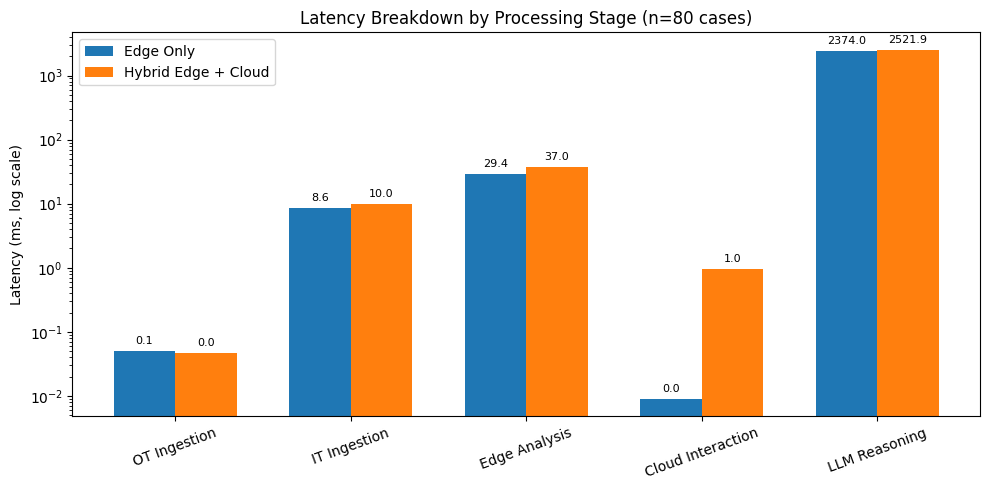

In [ ]:
# Final Improved Plot — Latency Breakdown by Processing Stage

x = np.arange(len(latency_breakdown_df["Component"]))
width = 0.35

plt.figure(figsize=(10, 5))

bars1 = plt.bar(x - width/2, latency_breakdown_df["Edge Only"], width, label="Edge Only")
bars2 = plt.bar(x + width/2, latency_breakdown_df["Hybrid Edge + Cloud"], width, label="Hybrid Edge + Cloud")

plt.xticks(x, latency_breakdown_df["Component"], rotation=20)
plt.ylabel("Latency (ms, log scale)")
plt.title("Latency Breakdown by Processing Stage (n=80 cases)")
plt.yscale("log")

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2,
                 height * 1.2,
                 f"{height:.1f}",
                 ha='center',
                 va='bottom',
                 fontsize=8)

plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Optional — Save AI4I figures

# Cloud interaction rate
plt.figure(figsize=(7, 4))
labels = ["Edge Only", "Hybrid Edge + Cloud"]
cloud_usage = [0, summary.loc[1, "Cloud Usage Rate"]]
bars = plt.bar(labels, cloud_usage)
plt.title(f"Cloud Interaction Rate (AI4I, n={len(results_edge_only)} cases)")
plt.ylabel("Fraction of Events")
plt.ylim(0, max(cloud_usage) + 0.05)
for bar in bars:
    height = bar.get_height()
    label = f"{height:.3f}" if height > 0.0001 else "0.000"
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.005, label, ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.savefig("ai4i_cloud_interaction_rate.png", dpi=300, bbox_inches="tight")
plt.show()

# Diagnostic quality
plt.figure(figsize=(7, 4))
labels = summary["Mode"]
values = summary["Diagnostic Quality Score"]
bars = plt.bar(labels, values)
plt.title(f"Diagnostic Quality Comparison (AI4I, n={len(results_edge_only)} cases)")
plt.ylabel("Quality Score")
plt.ylim(0, 1.05)
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.01, f"{height:.3f}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.savefig("ai4i_diagnostic_quality.png", dpi=300, bbox_inches="tight")
plt.show()

# Mean latency
plt.figure(figsize=(7, 4))
labels = summary["Mode"]
values = summary["Mean Latency (ms)"]
bars = plt.bar(labels, values)
plt.title(f"Average End-to-End Processing Latency (AI4I, n={len(results_edge_only)} cases)")
plt.ylabel("Latency (ms)")
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 40, f"{height:.1f}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.savefig("ai4i_mean_latency.png", dpi=300, bbox_inches="tight")
plt.show()

# Latency breakdown
x = np.arange(len(latency_breakdown_df["Component"]))
width = 0.35
plt.figure(figsize=(10, 5))
bars1 = plt.bar(x - width/2, latency_breakdown_df["Edge Only"], width, label="Edge Only")
bars2 = plt.bar(x + width/2, latency_breakdown_df["Hybrid Edge + Cloud"], width, label="Hybrid Edge + Cloud")
plt.xticks(x, latency_breakdown_df["Component"], rotation=20)
plt.ylabel("Latency (ms, log scale)")
plt.title(f"Latency Breakdown by Processing Stage (AI4I, n={len(results_edge_only)} cases)")
plt.yscale("log")
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        label = f"{height:.1f}" if height > 0.05 else "≈0"
        plt.text(bar.get_x() + bar.get_width()/2, height * 1.15, label, ha="center", va="bottom", fontsize=8)
plt.legend()
plt.tight_layout()
plt.savefig("ai4i_latency_breakdown.png", dpi=300, bbox_inches="tight")
plt.show()

Cell 16 — Show a Few Hybrid Cases

In [ ]:
# Cell 16 — Show Example Hybrid Cases

sample_cases = results_hybrid.sort_values(
    ["actual_failure", "anomaly_probability"],
    ascending=[False, False]
).head(3)

for idx, row in sample_cases.iterrows():
    print("=" * 100)
    print("Machine:", row["machine_id"])
    print("Actual failure type:", row["actual_failure_type"])
    print("Diagnosis:", row["diagnosis"])
    print("Cloud used:", row["cloud_used"])
    print("Latency (ms):", row["total_latency_ms"])
    print("LLM Explanation:")
    print(row["llm_explanation"])
    print()

Machine: CNC_5
Actual failure type: vibration_fault
Diagnosis: uncertain
Cloud used: True
Latency (ms): 3140.38
LLM Explanation:
1. **Most Likely Issue**: The machine is experiencing potential tool wear and vibration faults, as indicated by the telemetry data and cloud knowledge matches.

2. **Clear Cause**: The tool wear is at 61.34 minutes, which is significantly below the threshold of 210 minutes identified in the failure cases. However, the vibration level of 3.92 mm/s is above the average benchmark of 2.4 mm/s, suggesting possible spindle misalignment or bearing issues.

3. **Recommended Operator Action**: Inspect the cutting tool for wear and replace it if necessary. Additionally, check the spindle alignment and bearing condition to address the elevated vibration levels.

Machine: CNC_4
Actual failure type: vibration_fault
Diagnosis: uncertain
Cloud used: True
Latency (ms): 2730.92
LLM Explanation:
1. **Most Likely Issue**: The machine is experiencing tool wear, which is indicate

In [ ]:
summary.to_csv("ddak_connect_summary.csv", index=False)
results_hybrid.to_csv("ddak_connect_hybrid_results.csv", index=False)
results_edge_only.to_csv("ddak_connect_edge_results.csv", index=False)